## HRP VS EBC

First we implement EBC (same as Equal Beta Contribution notebook)

In [14]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt

In [15]:
ff_df = pd.read_csv("F-F_Research_Data_5_Factors_2x3.csv", index_col=0, skiprows=3)
ff_df = ff_df[ff_df.index.astype(str).str.match(r"^\d{6}$")]
ff_df.index = pd.to_datetime(ff_df.index.astype(str), format="%Y%m")


ff_df.index = ff_df.index + pd.offsets.MonthEnd(0)
ff_df = ff_df.apply(pd.to_numeric, errors='coerce') / 100
ff_df = ff_df.loc[(ff_df.index >= '1964-01-01') & (ff_df.index < '2025-01-01')]
ff_df.rename(columns={"RF": "RiskFreeRate"}, inplace=True)
ff_df.tail()

,Mkt-RF,SMB,HML,RMW,CMA,RiskFreeRate
2024-08-31,0.0161,-0.0356,-0.0110,0.0073,0.0082,0.0048
2024-09-30,0.0173,-0.0091,-0.0277,0.0018,-0.0029,0.0040
2024-10-31,-0.0100,-0.0088,0.0086,-0.0140,0.0098,0.0039
2024-11-30,0.0649,0.0462,0.0015,-0.0231,-0.0205,0.0040
2024-12-31,-0.0315,-0.0384,-0.0300,0.0191,-0.0121,0.0037


In [16]:
constituent_data = pd.read_csv('sp500_returns_with_tickers.csv')

# Parse 'date' column to datetime
constituent_data["date"] = pd.to_datetime(constituent_data["date"])

# Filter by date
constituent_data = constituent_data.loc[
    (constituent_data["date"] > '1963-12-31') &
    (constituent_data["date"] <= '2024-12-31')
]

# Set datetime index
constituent_data.set_index("date", inplace=True)

# Convert index to calendar month-end (regardless of Feb 28/29 or 30/31 issues)
constituent_data.index = constituent_data.index.to_period('M').to_timestamp('M')
tickers = constituent_data.columns
constituent_data.tail()

,ACF,ABK,AMT,JAVA,AN,ORCL,MSFT,SDS,AYE,TROW,...,CFN,AVGO,VRSK,DG.2,FTNT,VAL,GNRC,QEP,CBOE,TSLA
date,,,,,,,,,,,,,,,,,,,,,
2024-08-31,NaN,NaN,NaN,NaN,NaN,0.013195,-0.001100,NaN,NaN,-0.071535,...,NaN,0.013319,0.042292,-0.310823,0.321675,NaN,0.005460,NaN,0.122718,-0.077391
2024-09-30,NaN,NaN,NaN,NaN,NaN,0.206030,0.031548,NaN,NaN,0.038948,...,NaN,0.062707,-0.016385,0.019284,0.010950,NaN,0.015013,NaN,-0.002580,0.221942
2024-10-31,NaN,NaN,NaN,NaN,NaN,-0.012676,-0.055659,NaN,NaN,0.008538,...,NaN,-0.015826,0.025228,-0.046589,0.014313,NaN,0.041981,NaN,0.042466,-0.045025
2024-11-30,NaN,NaN,NaN,NaN,NaN,0.101287,0.044149,NaN,NaN,0.127253,...,NaN,-0.045297,0.070945,-0.034608,0.208365,NaN,0.136817,NaN,0.013626,0.381469
2024-12-31,NaN,NaN,NaN,NaN,NaN,-0.098464,-0.004629,NaN,NaN,-0.076793,...,NaN,0.434045,-0.062506,-0.018765,-0.005997,NaN,-0.176142,NaN,-0.094742,0.170008


In [17]:
excess_returns = constituent_data.subtract(ff_df['RiskFreeRate'], axis=0)
factor_data = ff_df.drop(columns=["RiskFreeRate"])
factor_data["Mkt-RF"]

1964-01-31    0.0227
1964-02-29    0.0155
1964-03-31    0.0141
1964-04-30    0.0011
1964-05-31    0.0141
               ...  
2024-08-31    0.0161
2024-09-30    0.0173
2024-10-31   -0.0100
2024-11-30    0.0649
2024-12-31   -0.0315
Name: Mkt-RF, Length: 732, dtype: float64

In [18]:
merged_df = pd.concat([excess_returns, ff_df], axis=1)
merged_df

,ACF,ABK,AMT,JAVA,AN,ORCL,MSFT,SDS,AYE,TROW,...,GNRC,QEP,CBOE,TSLA,Mkt-RF,SMB,HML,RMW,CMA,RiskFreeRate
1964-01-31,0.065548,-0.031846,0.066915,NaN,0.026083,NaN,NaN,NaN,-0.010371,NaN,...,NaN,NaN,NaN,NaN,0.0227,0.0010,0.0163,0.0021,0.0148,0.0030
1964-02-29,0.041174,0.032054,0.053400,NaN,-0.030861,NaN,NaN,NaN,0.037004,NaN,...,NaN,NaN,NaN,NaN,0.0155,0.0033,0.0281,0.0011,0.0081,0.0026
1964-03-31,-0.003100,0.044268,0.078339,NaN,0.067036,NaN,NaN,NaN,0.020710,NaN,...,NaN,NaN,NaN,NaN,0.0141,0.0141,0.0329,-0.0203,0.0298,0.0031
1964-04-30,0.000736,-0.032923,-0.016911,NaN,-0.049412,NaN,NaN,NaN,-0.038111,NaN,...,NaN,NaN,NaN,NaN,0.0011,-0.0148,-0.0054,-0.0132,-0.0113,0.0029
1964-05-31,-0.013470,0.025971,-0.020521,NaN,-0.040294,NaN,NaN,NaN,-0.019632,NaN,...,NaN,NaN,NaN,NaN,0.0141,-0.0062,0.0181,-0.0015,0.0013,0.0026
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-08-31,NaN,NaN,NaN,NaN,NaN,0.008395,-0.005900,NaN,NaN,-0.076335,...,0.000660,NaN,0.117918,-0.082191,0.0161,-0.0356,-0.0110,0.0073,0.0082,0.0048
2024-09-30,NaN,NaN,NaN,NaN,NaN,0.202030,0.027548,NaN,NaN,0.034948,...,0.011013,NaN,-0.006580,0.217942,0.0173,-0.0091,-0.0277,0.0018,-0.0029,0.0040
2024-10-31,NaN,NaN,NaN,NaN,NaN,-0.016576,-0.059559,NaN,NaN,0.004638,...,0.038081,NaN,0.038566,-0.048925,-0.0100,-0.0088,0.0086,-0.0140,0.0098,0.0039
2024-11-30,NaN,NaN,NaN,NaN,NaN,0.097287,0.040149,NaN,NaN,0.123253,...,0.132817,NaN,0.009626,0.377469,0.0649,0.0462,0.0015,-0.0231,-0.0205,0.0040


In [19]:
def compute_rolling_betas_and_alpha(
    excess_returns_df,
    factor_df,
    portfolio_col,
    window=24,
    beta_MKT=True,
    beta_SMB=False,
    beta_HML=False,
    beta_RMW=False,
    beta_CMA=False,
    beta_Momentum=False
):
    """computes rolling betas and alphas"""
    factor_flags = {
        "Mkt-RF": beta_MKT,
        "SMB": beta_SMB,
        "HML": beta_HML,
        "RMW": beta_RMW,
        "CMA": beta_CMA,
        "Mom": beta_Momentum
    }

    selected_factors = [factor for factor, include in factor_flags.items() if include]

    results = {"alpha": []}
    for factor in selected_factors:
        results[f"beta_{factor}"] = []

    index = []

    for i in range(window, len(excess_returns_df)):
        y = excess_returns_df[portfolio_col].iloc[i - window:i]
        X = factor_df[selected_factors].iloc[i - window:i]

        #drop rows with nans
        valid = y.notna() & X.notna().all(axis=1)
        if valid.sum() < window:
            continue

        y = y[valid]
        X = X[valid]

        X = sm.add_constant(X)
        model = sm.OLS(y, X).fit()

        results["alpha"].append(model.params.get("const", float("nan")))
        for factor in selected_factors:
            results[f"beta_{factor}"].append(model.params.get(factor, float("nan")))

        index.append(excess_returns_df.index[i])

    return pd.DataFrame(results, index=index)

In [20]:
rolling_betas = []

for ticker in tickers:
    try:
        betas = compute_rolling_betas_and_alpha(
    excess_returns_df=excess_returns,
    factor_df=factor_data,
    portfolio_col=ticker,
    window=36,
    beta_MKT=True,
    beta_SMB=False,
    beta_HML=False,
    beta_RMW=False,
    beta_CMA=False
)
        betas["ticker"] = ticker
        rolling_betas.append(betas)
    except Exception as e:
        print(f"Error for {ticker}: {e}")

beta_df = pd.concat(rolling_betas).reset_index().rename(columns={"index": "date"})

/var/folders/6k/mln8cd4525b_jmbk_djkjych0000gn/T/ipykernel_18758/47437094.py:21: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.
  beta_df = pd.concat(rolling_betas).reset_index().rename(columns={"index": "date"})


In [21]:
beta_df

,date,alpha,beta_Mkt-RF,ticker
0,1967-01-31,0.004128,1.368421,ACF
1,1967-02-28,0.003717,1.403478,ACF
2,1967-03-31,0.001825,1.389848,ACF
3,1967-04-30,0.004618,1.509165,ACF
4,1967-05-31,0.004460,1.493075,ACF
...,...,...,...,...
302538,2024-08-31,0.004466,1.880977,TSLA
302539,2024-09-30,0.001002,1.864024,TSLA
302540,2024-10-31,0.001759,1.960413,TSLA
302541,2024-11-30,-0.006656,1.750627,TSLA


In [22]:
beta_mkt_matrix = beta_df.pivot_table(
    index="date",
    columns="ticker",
    values="beta_Mkt-RF"
)

beta_mkt_matrix = beta_mkt_matrix.dropna(how='all')
beta_mkt_matrix

ticker,A,A.1,AAF,AAL,AAL.1,AAP,AAPL,AAV,ABA,ABBV,...,YHOO,YUM,ZA,ZB,ZBH,ZBRA,ZE,ZION,ZRN,ZTS
date,,,,,,,,,,,,,,,,,,,,,
1967-01-31,2.217403,NaN,NaN,2.013581,NaN,NaN,NaN,NaN,0.979182,NaN,...,NaN,NaN,1.279400,1.011713,NaN,NaN,1.076971,NaN,NaN,NaN
1967-02-28,2.165327,NaN,NaN,1.982664,NaN,NaN,NaN,NaN,1.160762,NaN,...,NaN,NaN,1.845629,0.914638,NaN,NaN,1.348319,NaN,NaN,NaN
1967-03-31,2.151039,NaN,NaN,1.922360,NaN,NaN,NaN,NaN,1.149658,NaN,...,NaN,NaN,1.820075,0.907140,NaN,NaN,1.344366,NaN,NaN,NaN
1967-04-30,1.999157,NaN,NaN,1.929657,NaN,NaN,NaN,NaN,1.303296,NaN,...,NaN,NaN,1.660824,0.961084,NaN,NaN,1.202130,NaN,NaN,NaN
1967-05-31,1.949958,NaN,NaN,1.882047,NaN,NaN,NaN,NaN,1.326681,NaN,...,NaN,NaN,1.562404,1.052422,NaN,NaN,1.329979,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-08-31,NaN,1.214030,NaN,1.305132,NaN,NaN,1.171161,NaN,NaN,0.440932,...,NaN,0.705485,NaN,NaN,0.703270,1.673707,NaN,NaN,NaN,1.001442
2024-09-30,NaN,1.182548,NaN,1.314620,NaN,NaN,1.171067,NaN,NaN,0.441901,...,NaN,0.710847,NaN,NaN,0.730322,1.661869,NaN,NaN,NaN,1.005565
2024-10-31,NaN,1.163425,NaN,NaN,NaN,NaN,1.156716,NaN,NaN,0.383366,...,NaN,0.695131,NaN,NaN,0.731116,1.652117,NaN,NaN,NaN,1.011549


In [23]:
import numpy as np
import pandas as pd
from scipy.optimize import minimize

def equal_abs_beta_contribution_weights(beta_row):
    #filter out nans and zero betas
    valid_betas = beta_row.dropna()
    valid_betas = valid_betas[valid_betas != 0]

    if valid_betas.empty:
        return pd.Series(dtype=float)

    betas = valid_betas.values
    n = len(betas)
    idx = valid_betas.index

    #objective function to minimize with target of 1/n
    def objective(w):
        contrib = w * betas
        return np.sum((contrib - 1/n)**2)

    #constraints: sum of weights = 1
    constraints = [
        {'type': 'eq', 'fun': lambda w: np.sum(w) - 1},
    ]

    #long only weights to mimic equal weight
    bounds = [(0, 1) for _ in range(n)]

    #start with inverted betas
    x0 = 1 / np.abs(betas)
    x0 = x0 / x0.sum()

    result = minimize(objective, x0, bounds=bounds, constraints=constraints)

    if not result.success:
        return pd.Series(dtype=float)

    weights = pd.Series(result.x, index=idx)

    full_weights = pd.Series(0.0, index=beta_row.index)
    full_weights.update(weights)

    return full_weights

In [24]:
from tqdm import tqdm
all_tickers = beta_mkt_matrix.columns
tqdm.pandas()

equal_abs_beta_weights = beta_mkt_matrix.progress_apply(
    lambda row: equal_abs_beta_contribution_weights(row).reindex(all_tickers, fill_value=0),
    axis=1
)

100%|██████████| 696/696 [59:17<00:00,  5.11s/it]    


In [25]:
equal_abs_beta_weights

ticker,A,A.1,AAF,AAL,AAL.1,AAP,AAPL,AAV,ABA,ABBV,...,YHOO,YUM,ZA,ZB,ZBH,ZBRA,ZE,ZION,ZRN,ZTS
date,,,,,,,,,,,,,,,,,,,,,
1967-01-31,0.001002,0.000000,0.0,0.001041,0.0,0.0,0.000000,0.0,0.002034,0.000000,...,0.0,0.000000,0.001633,0.001978,0.000000,0.000000,0.001902,0.0,0.0,0.000000
1967-02-28,0.001010,0.000000,0.0,0.001107,0.0,0.0,0.000000,0.0,0.001835,0.000000,...,0.0,0.000000,0.001137,0.002339,0.000000,0.000000,0.001531,0.0,0.0,0.000000
1967-03-31,0.000977,0.000000,0.0,0.001094,0.0,0.0,0.000000,0.0,0.001831,0.000000,...,0.0,0.000000,0.001183,0.002301,0.000000,0.000000,0.001581,0.0,0.0,0.000000
1967-04-30,0.001073,0.000000,0.0,0.001091,0.0,0.0,0.000000,0.0,0.001602,0.000000,...,0.0,0.000000,0.001270,0.002080,0.000000,0.000000,0.001695,0.0,0.0,0.000000
1967-05-31,0.001065,0.000000,0.0,0.001124,0.0,0.0,0.000000,0.0,0.001559,0.000000,...,0.0,0.000000,0.001312,0.001902,0.000000,0.000000,0.001555,0.0,0.0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-08-31,0.000000,0.001612,0.0,0.001466,0.0,0.0,0.001720,0.0,0.000000,0.003488,...,0.0,0.002517,0.000000,0.000000,0.002524,0.001179,0.000000,0.0,0.0,0.001876
2024-09-30,0.000000,0.001674,0.0,0.001483,0.0,0.0,0.001680,0.0,0.000000,0.003865,...,0.0,0.002578,0.000000,0.000000,0.002521,0.001247,0.000000,0.0,0.0,0.001933
2024-10-31,0.000000,0.001701,0.0,0.000000,0.0,0.0,0.001715,0.0,0.000000,0.003699,...,0.0,0.002607,0.000000,0.000000,0.002493,0.001204,0.000000,0.0,0.0,0.001867


In [26]:
returns_aligned = constituent_data.loc[equal_abs_beta_weights.index, equal_abs_beta_weights.columns]

assert equal_abs_beta_weights.shape == returns_aligned.shape
assert equal_abs_beta_weights.columns.equals(returns_aligned.columns)
assert equal_abs_beta_weights.index.equals(returns_aligned.index)


weighted_returns = equal_abs_beta_weights * returns_aligned

equal_beta_portfolio_return = weighted_returns.sum(axis=1)

In [27]:
equal_beta_portfolio_return

date
1967-01-31    0.105809
1967-02-28    0.007303
1967-03-31    0.043577
1967-04-30    0.032736
1967-05-31   -0.027935
                ...   
2024-08-31    0.030202
2024-09-30    0.016253
2024-10-31   -0.016896
2024-11-30    0.054184
2024-12-31   -0.063435
Length: 696, dtype: float64

In [28]:
equal_beta_portfolio_return.to_csv("equal_beta_portfolio_return.csv", header=True)

In [29]:
equal_beta_portfolio_return.index = equal_beta_portfolio_return.index - pd.offsets.MonthEnd(1) + pd.offsets.MonthBegin(1)

print(equal_beta_portfolio_return.head())

date
1967-01-01    0.105809
1967-02-01    0.007303
1967-03-01    0.043577
1967-04-01    0.032736
1967-05-01   -0.027935
dtype: float64


In [30]:
sp500_returns = pd.read_csv("sp500_capweighted_returns.csv")
sp500_returns['date'] = pd.to_datetime(sp500_returns['date'])
sp500_returns.set_index('date', inplace=True)
sp500_returns.index = sp500_returns.index - pd.offsets.MonthEnd(1) + pd.offsets.MonthBegin(1)
sp500_returns

,0
date,
1960-01-01,-0.067093
1960-02-01,0.017111
1960-03-01,-0.010623
1960-04-01,-0.013724
1960-05-01,0.037913
...,...
2024-08-01,0.028116
2024-09-01,0.025856
2024-10-01,-0.004786


In [31]:
common_index = sp500_returns.index.intersection(equal_beta_portfolio_return.index)
sp500_returns = sp500_returns.loc[common_index]
equal_beta_portfolio_return = equal_beta_portfolio_return.loc[common_index]
sp500_returns.columns = ["S&P 500 Return"]
equal_beta_portfolio_return = equal_beta_portfolio_return.to_frame(name="EBC Return")
equal_beta_portfolio_return

,EBC Return
date,
1967-01-01,0.105809
1967-02-01,0.007303
1967-03-01,0.043577
1967-04-01,0.032736
1967-05-01,-0.027935
...,...
2024-08-01,0.030202
2024-09-01,0.016253
2024-10-01,-0.016896


In [32]:
spread = sp500_returns["S&P 500 Return"] - equal_beta_portfolio_return["EBC Return"]
spread = spread.to_frame(name="Spread Return")
spread

,Spread Return
date,
1967-01-01,-0.022394
1967-02-01,0.002736
1967-03-01,0.000430
1967-04-01,0.014722
1967-05-01,-0.016680
...,...
2024-08-01,-0.002086
2024-09-01,0.009603
2024-10-01,0.012110


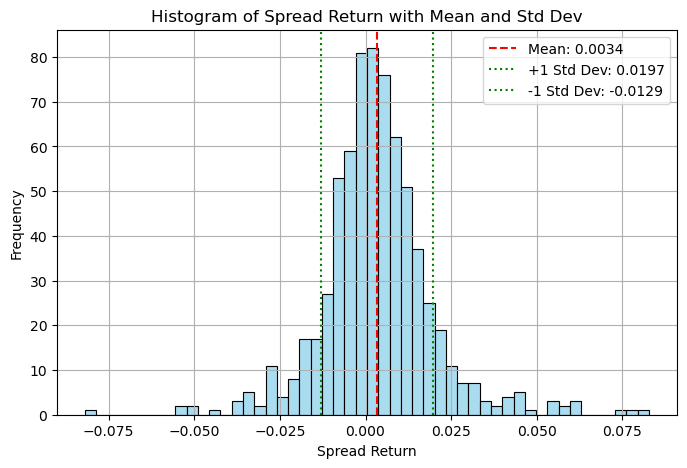

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

#mean and std
mean_val = spread['Spread Return'].mean()
std_val = spread['Spread Return'].std()

plt.figure(figsize=(8,5))
sns.histplot(spread['Spread Return'], bins=50, kde=False, color='skyblue', alpha=0.7)


plt.axvline(mean_val, color='red', linestyle='--', label=f'Mean: {mean_val:.4f}')


plt.axvline(mean_val + std_val, color='green', linestyle=':', label=f'+1 Std Dev: {mean_val + std_val:.4f}')
plt.axvline(mean_val - std_val, color='green', linestyle=':', label=f'-1 Std Dev: {mean_val - std_val:.4f}')

plt.title("Histogram of Spread Return with Mean and Std Dev")
plt.xlabel("Spread Return")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)
plt.show()



In [34]:
equal_abs_beta_weights

ticker,A,A.1,AAF,AAL,AAL.1,AAP,AAPL,AAV,ABA,ABBV,...,YHOO,YUM,ZA,ZB,ZBH,ZBRA,ZE,ZION,ZRN,ZTS
date,,,,,,,,,,,,,,,,,,,,,
1967-01-31,0.001002,0.000000,0.0,0.001041,0.0,0.0,0.000000,0.0,0.002034,0.000000,...,0.0,0.000000,0.001633,0.001978,0.000000,0.000000,0.001902,0.0,0.0,0.000000
1967-02-28,0.001010,0.000000,0.0,0.001107,0.0,0.0,0.000000,0.0,0.001835,0.000000,...,0.0,0.000000,0.001137,0.002339,0.000000,0.000000,0.001531,0.0,0.0,0.000000
1967-03-31,0.000977,0.000000,0.0,0.001094,0.0,0.0,0.000000,0.0,0.001831,0.000000,...,0.0,0.000000,0.001183,0.002301,0.000000,0.000000,0.001581,0.0,0.0,0.000000
1967-04-30,0.001073,0.000000,0.0,0.001091,0.0,0.0,0.000000,0.0,0.001602,0.000000,...,0.0,0.000000,0.001270,0.002080,0.000000,0.000000,0.001695,0.0,0.0,0.000000
1967-05-31,0.001065,0.000000,0.0,0.001124,0.0,0.0,0.000000,0.0,0.001559,0.000000,...,0.0,0.000000,0.001312,0.001902,0.000000,0.000000,0.001555,0.0,0.0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-08-31,0.000000,0.001612,0.0,0.001466,0.0,0.0,0.001720,0.0,0.000000,0.003488,...,0.0,0.002517,0.000000,0.000000,0.002524,0.001179,0.000000,0.0,0.0,0.001876
2024-09-30,0.000000,0.001674,0.0,0.001483,0.0,0.0,0.001680,0.0,0.000000,0.003865,...,0.0,0.002578,0.000000,0.000000,0.002521,0.001247,0.000000,0.0,0.0,0.001933
2024-10-31,0.000000,0.001701,0.0,0.000000,0.0,0.0,0.001715,0.0,0.000000,0.003699,...,0.0,0.002607,0.000000,0.000000,0.002493,0.001204,0.000000,0.0,0.0,0.001867


In [35]:
import numpy as np
import pandas as pd

def distance_from_equal_weights(row):
    #non nan and 0
    active = row[(row.notna()) & (row != 0)]

    if active.empty:
        return np.nan

    n_active = len(active)
    equal_w = 1 / n_active

    #equal weights
    equal_weights = pd.Series(equal_w, index=active.index)

    # euclidean distance
    dist = np.linalg.norm(active.values - equal_weights.values)
    return dist

#apply to each row
distance_series = equal_abs_beta_weights.apply(distance_from_equal_weights, axis=1)
distance_series.name = "Distance from Equal Weights (active stocks only)"


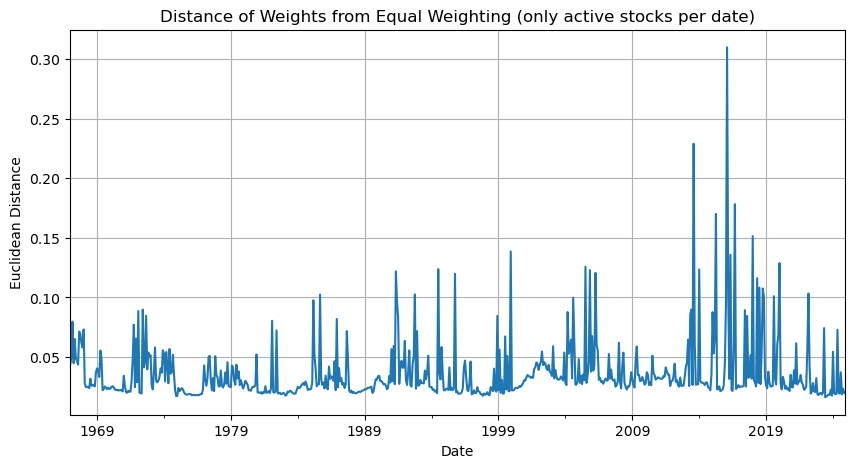

In [36]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
distance_series.plot()
plt.title("Distance of Weights from Equal Weighting (only active stocks per date)")
plt.ylabel("Euclidean Distance")
plt.xlabel("Date")
plt.grid(True)
plt.show()


In [37]:
max_dist_date = distance_series.idxmax()
weights_on_max_dist_date = equal_abs_beta_weights.loc[max_dist_date]
nonzero_weights = weights_on_max_dist_date[weights_on_max_dist_date != 0]
nonzero_weights

ticker
A.1      0.001388
AAPL     0.001434
ABBV     0.001194
ABT      0.001309
ACN.1    0.001874
           ...   
XYL      0.001412
YHOO     0.000907
YUM      0.001966
ZBH      0.001676
ZION     0.001464
Name: 2016-02-29 00:00:00, Length: 423, dtype: float64

In [38]:
max_weight = nonzero_weights.max()
max_weight = nonzero_weights.max()
max_weight_ticker = nonzero_weights.idxmax()
print(f"Max weight: {max_weight:.4f} (Ticker: {max_weight_ticker})")

Max weight: 0.3117 (Ticker: EXC)


In [39]:
beta_value = beta_mkt_matrix.loc[max_dist_date, max_weight_ticker]
print(f"Beta of {max_weight_ticker} on {max_dist_date}: {beta_value}")

Beta of EXC on 2016-02-29 00:00:00: 0.002301364284780859


In [40]:
weighted_betas = equal_abs_beta_weights * beta_mkt_matrix

#contribtion data frame
print(f"Weighted betas: {weighted_betas}")

#weighted sum to see ecb beta
portfolio_beta = weighted_betas.sum(axis=1)
print(portfolio_beta.tail())


Weighted betas: ticker             A       A.1  AAF       AAL  AAL.1  AAP      AAPL  AAV  \
date                                                                       
1967-01-31  0.002222       NaN  NaN  0.002097    NaN  NaN       NaN  NaN   
1967-02-28  0.002187       NaN  NaN  0.002194    NaN  NaN       NaN  NaN   
1967-03-31  0.002101       NaN  NaN  0.002102    NaN  NaN       NaN  NaN   
1967-04-30  0.002145       NaN  NaN  0.002105    NaN  NaN       NaN  NaN   
1967-05-31  0.002078       NaN  NaN  0.002115    NaN  NaN       NaN  NaN   
...              ...       ...  ...       ...    ...  ...       ...  ...   
2024-08-31       NaN  0.001957  NaN  0.001913    NaN  NaN  0.002015  NaN   
2024-09-30       NaN  0.001980  NaN  0.001950    NaN  NaN  0.001968  NaN   
2024-10-31       NaN  0.001979  NaN       NaN    NaN  NaN  0.001984  NaN   
2024-11-30       NaN  0.001956  NaN       NaN    NaN  NaN  0.001993  NaN   
2024-12-31       NaN  0.001975  NaN       NaN    NaN  NaN  0.002024  NaN

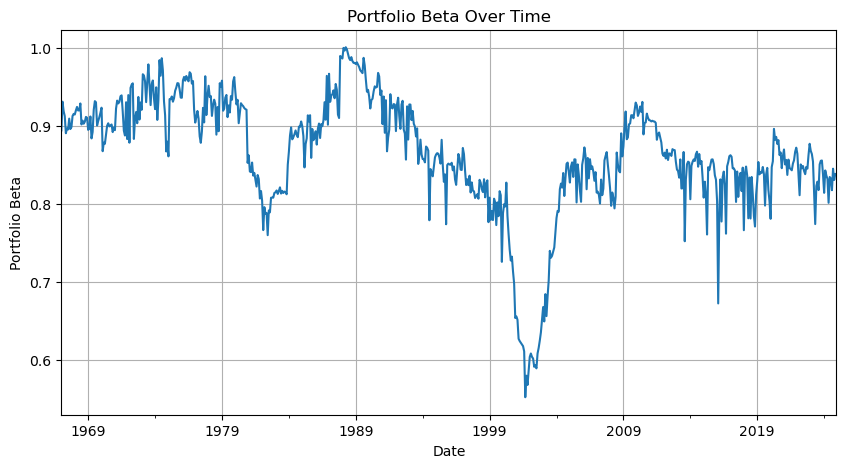

In [41]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
portfolio_beta.plot()
plt.title("Portfolio Beta Over Time")
plt.xlabel("Date")
plt.ylabel("Portfolio Beta")
plt.grid(True)
plt.show()


In [42]:
cum_spread_return = np.log1p(spread["Spread Return"]).cumsum()
sp_cum_return = np.log1p(sp500_returns["S&P 500 Return"]).cumsum()
EBC_cum_return = np.log1p(equal_beta_portfolio_return["EBC Return"]).cumsum()
target_index = EBC_cum_return.index
target_index

DatetimeIndex(['1967-01-01', '1967-02-01', '1967-03-01', '1967-04-01',
               '1967-05-01', '1967-06-01', '1967-07-01', '1967-08-01',
               '1967-09-01', '1967-10-01',
               ...
               '2024-03-01', '2024-04-01', '2024-05-01', '2024-06-01',
               '2024-07-01', '2024-08-01', '2024-09-01', '2024-10-01',
               '2024-11-01', '2024-12-01'],
              dtype='datetime64[ns]', name='date', length=696, freq=None)

In [43]:

preference = pd.read_csv("Preference Returns.csv", index_col=0, parse_dates=True)
preference.index = pd.to_datetime(preference.index).to_period("M").to_timestamp()
preference_cum_return = np.log1p(preference["Preference Return"]).cumsum()
preference_cum_return = preference_cum_return.loc[target_index]

In [44]:
combined_returns = pd.DataFrame({
    "Spread Return": cum_spread_return,
    # "S&P Return": sp_cum_return,
    # "EBC Return": EBC_cum_return,
    "Preference": preference_cum_return
}, index=target_index)

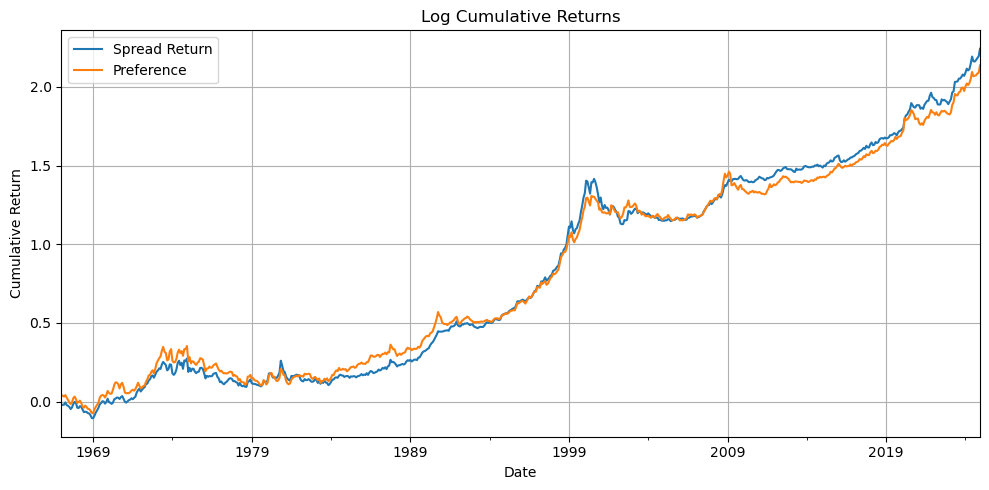

In [45]:
plt.figure(figsize=(10, 5))
combined_returns.plot(ax=plt.gca())
plt.title("Log Cumulative Returns")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [100]:
combined_returns = pd.DataFrame({
    "Spread Return": cum_spread_return,
    "S&P Return": sp_cum_return,
    "EBC Return": EBC_cum_return,
    "Preference": preference_cum_return
}, index=target_index)

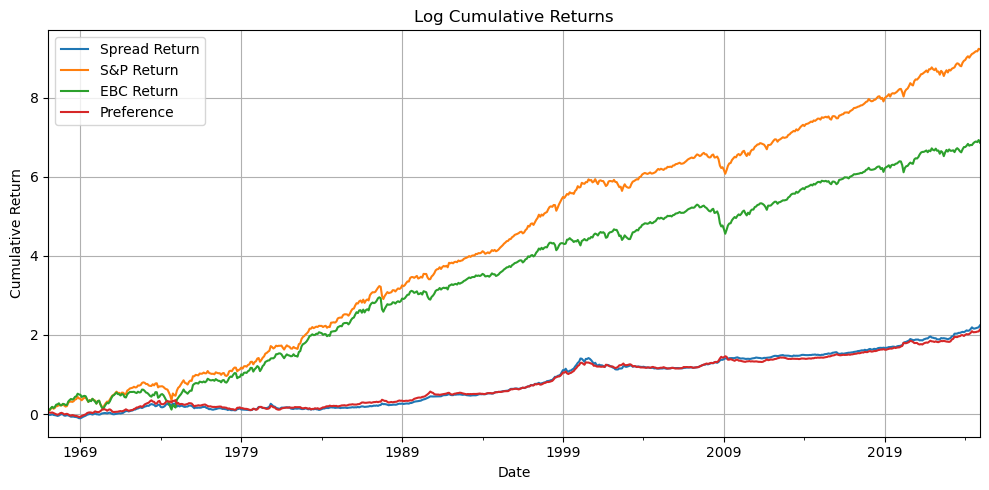

In [47]:
plt.figure(figsize=(10, 5))
combined_returns.plot(ax=plt.gca())
plt.title("Log Cumulative Returns")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [48]:
mag7 = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'META', 'NVDA', 'TSLA']  # adjust if using tickers like 'GOOG' or 'FB'
mag7_returns = excess_returns[mag7].copy()

In [49]:
betas_pref = {}
betas_spread = {}

for ticker in mag7:
    returns_ticker = excess_returns[ticker].dropna()

    # intersect with factor dates
    valid_index = returns_ticker.index.intersection(preference.index).intersection(spread.index)
    if len(valid_index) < 36:  # need enough data
        continue

    df = pd.DataFrame({
        "y": returns_ticker.loc[valid_index],
        "Preference": preference.loc[valid_index]["Preference Return"],
        "Spread": spread.loc[valid_index]["Spread Return"]
    }).dropna()

    if len(df) < 24:
        continue  # not enough data to estimate beta reliably

    X = sm.add_constant(df[["Preference", "Spread"]])
    y = df["y"]
    model = sm.OLS(y, X).fit()

    betas_pref[ticker] = model.params["Preference"]
    betas_spread[ticker] = model.params["Spread"]

# Beta matrix
beta_df_fm = pd.DataFrame({
    "beta_pref": betas_pref,
    "beta_spread": betas_spread
}).dropna()


In [50]:
equal_abs_beta_weights

ticker,A,A.1,AAF,AAL,AAL.1,AAP,AAPL,AAV,ABA,ABBV,...,YHOO,YUM,ZA,ZB,ZBH,ZBRA,ZE,ZION,ZRN,ZTS
date,,,,,,,,,,,,,,,,,,,,,
1967-01-31,0.001002,0.000000,0.0,0.001041,0.0,0.0,0.000000,0.0,0.002034,0.000000,...,0.0,0.000000,0.001633,0.001978,0.000000,0.000000,0.001902,0.0,0.0,0.000000
1967-02-28,0.001010,0.000000,0.0,0.001107,0.0,0.0,0.000000,0.0,0.001835,0.000000,...,0.0,0.000000,0.001137,0.002339,0.000000,0.000000,0.001531,0.0,0.0,0.000000
1967-03-31,0.000977,0.000000,0.0,0.001094,0.0,0.0,0.000000,0.0,0.001831,0.000000,...,0.0,0.000000,0.001183,0.002301,0.000000,0.000000,0.001581,0.0,0.0,0.000000
1967-04-30,0.001073,0.000000,0.0,0.001091,0.0,0.0,0.000000,0.0,0.001602,0.000000,...,0.0,0.000000,0.001270,0.002080,0.000000,0.000000,0.001695,0.0,0.0,0.000000
1967-05-31,0.001065,0.000000,0.0,0.001124,0.0,0.0,0.000000,0.0,0.001559,0.000000,...,0.0,0.000000,0.001312,0.001902,0.000000,0.000000,0.001555,0.0,0.0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-08-31,0.000000,0.001612,0.0,0.001466,0.0,0.0,0.001720,0.0,0.000000,0.003488,...,0.0,0.002517,0.000000,0.000000,0.002524,0.001179,0.000000,0.0,0.0,0.001876
2024-09-30,0.000000,0.001674,0.0,0.001483,0.0,0.0,0.001680,0.0,0.000000,0.003865,...,0.0,0.002578,0.000000,0.000000,0.002521,0.001247,0.000000,0.0,0.0,0.001933
2024-10-31,0.000000,0.001701,0.0,0.000000,0.0,0.0,0.001715,0.0,0.000000,0.003699,...,0.0,0.002607,0.000000,0.000000,0.002493,0.001204,0.000000,0.0,0.0,0.001867


In [51]:
nonzero_weights

ticker
A.1      0.001388
AAPL     0.001434
ABBV     0.001194
ABT      0.001309
ACN.1    0.001874
           ...   
XYL      0.001412
YHOO     0.000907
YUM      0.001966
ZBH      0.001676
ZION     0.001464
Name: 2016-02-29 00:00:00, Length: 423, dtype: float64

In [54]:
combined_returns

,Spread Return,S&P Return,EBC Return,Preference
date,,,,
1967-01-01,-0.022648,0.080118,0.100577,0.037601
1967-02-01,-0.019916,0.090107,0.107854,0.038634
1967-03-01,-0.019487,0.133173,0.150508,0.032060
1967-04-01,-0.004873,0.179539,0.182720,0.041795
1967-05-01,-0.021693,0.133898,0.154387,0.025543
...,...,...,...,...
2024-08-01,2.160508,9.146234,6.873690,2.070509
2024-09-01,2.170065,9.171762,6.889812,2.073066
2024-10-01,2.182102,9.166964,6.872771,2.084622


## HRP

In [56]:
from pypfopt.hierarchical_portfolio import HRPOpt

In [57]:

def rolling_hrp_weights(
    returns: pd.DataFrame,
    window: int = 36,
    min_non_na_frac: float = 0.8
) -> pd.DataFrame:
    """
    Compute rolling HRP weights using a trailing window.
    Parameters
    ----------
    returns : DataFrame (dates x tickers) of arithmetic returns at your desired rebalance frequency (e.g., monthly)
    window : trailing lookback window length in periods
    min_non_na_frac : minimum fraction of non-NaN observations required in the window for a column to be included
    Returns
    -------
    DataFrame of HRP weights indexed by rebalance dates.
    """
    rets = returns.copy()
    W_list, dates = [], []

    thresh = int(np.ceil(min_non_na_frac * window))

    for dt in rets.index[window:]:
        hist = rets.loc[:dt].iloc[-window:]
        # drop assets with too many NaNs
        hist = hist.dropna(axis=1, thresh=thresh)
        if hist.shape[1] < 2:
            continue

        hrp = HRPOpt(returns=hist)
        w_dict = hrp.optimize()  # dict of weights
        w = pd.Series(w_dict).reindex(rets.columns).fillna(0.0)

        W_list.append(w)
        dates.append(dt)

    if not W_list:
        return pd.DataFrame(index=rets.index, columns=rets.columns, data=np.nan)

    W = pd.DataFrame(W_list, index=pd.DatetimeIndex(dates))
    # enforce simplex
    W = W.clip(lower=0.0)
    W = W.div(W.sum(axis=1), axis=0).fillna(0.0)
    return W


def hrp_portfolio_returns(
    returns: pd.DataFrame,
    weights: pd.DataFrame
) -> pd.Series:
    """
    Apply HRP weights with a one-period look-ahead offset to avoid look-ahead bias.
    Returns a portfolio return series aligned to the returns frequency.
    """
    rets = returns.copy()
    W = weights.reindex(rets.index).ffill().shift(1)  # use weights decided at t-1
    port = (W * rets).sum(axis=1)
    port.name = "HRP"
    return port


In [58]:
returns_aligned

ticker,A,A.1,AAF,AAL,AAL.1,AAP,AAPL,AAV,ABA,ABBV,...,YHOO,YUM,ZA,ZB,ZBH,ZBRA,ZE,ZION,ZRN,ZTS
date,,,,,,,,,,,,,,,,,,,,,
1967-01-31,0.156250,NaN,NaN,0.173913,NaN,NaN,NaN,NaN,0.144000,NaN,...,NaN,NaN,0.314103,0.033708,NaN,NaN,0.194737,NaN,NaN,NaN
1967-02-28,-0.044595,NaN,NaN,-0.024691,NaN,NaN,NaN,NaN,-0.006993,NaN,...,NaN,NaN,-0.152195,-0.005435,NaN,NaN,0.011013,NaN,NaN,NaN
1967-03-31,-0.046676,NaN,NaN,0.125596,NaN,NaN,NaN,NaN,0.161972,NaN,...,NaN,NaN,-0.069364,0.072131,NaN,NaN,-0.049238,NaN,NaN,NaN
1967-04-30,0.055556,NaN,NaN,0.053672,NaN,NaN,NaN,NaN,0.073620,NaN,...,NaN,NaN,-0.037267,0.121134,NaN,NaN,0.191244,NaN,NaN,NaN
1967-05-31,0.049787,NaN,NaN,-0.086863,NaN,NaN,NaN,NaN,0.005714,NaN,...,NaN,NaN,0.069677,-0.080460,NaN,NaN,-0.100580,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-08-31,NaN,0.010750,NaN,-0.001880,NaN,NaN,0.032286,NaN,NaN,0.059303,...,NaN,0.020778,NaN,NaN,0.036911,-0.016544,NaN,NaN,NaN,0.019163
2024-09-30,NaN,0.038903,NaN,NaN,NaN,NaN,0.017467,NaN,NaN,0.005960,...,NaN,0.035503,NaN,NaN,-0.062966,0.072210,NaN,NaN,NaN,0.064799
2024-10-31,NaN,-0.120784,NaN,NaN,NaN,NaN,-0.030429,NaN,NaN,0.040207,...,NaN,-0.061198,NaN,NaN,-0.009541,0.031459,NaN,NaN,NaN,-0.082752


In [59]:
window = 36
W_hrp = rolling_hrp_weights(returns_aligned, window=window)
hrp_port = hrp_portfolio_returns(returns_aligned, W_hrp)

In [60]:
W_hrp

ticker,A,A.1,AAF,AAL,AAL.1,AAP,AAPL,AAV,ABA,ABBV,...,YHOO,YUM,ZA,ZB,ZBH,ZBRA,ZE,ZION,ZRN,ZTS
1970-01-31,0.001116,0.000000,0.0,0.000450,0.0,0.0,0.000000,0.0,0.000775,0.000000,...,0.0,0.000000,0.001400,0.001365,0.000000,0.000000,0.002513,0.000000,0.0,0.000000
1970-02-28,0.001505,0.000000,0.0,0.000374,0.0,0.0,0.000000,0.0,0.000729,0.000000,...,0.0,0.000000,0.001354,0.001748,0.000000,0.000000,0.001303,0.000000,0.0,0.000000
1970-03-31,0.001256,0.000000,0.0,0.000398,0.0,0.0,0.000000,0.0,0.000794,0.000000,...,0.0,0.000000,0.001188,0.001164,0.000000,0.000000,0.001207,0.000000,0.0,0.000000
1970-04-30,0.001196,0.000000,0.0,0.000407,0.0,0.0,0.000000,0.0,0.000752,0.000000,...,0.0,0.000000,0.001466,0.001209,0.000000,0.000000,0.001238,0.000000,0.0,0.000000
1970-05-31,0.001712,0.000000,0.0,0.000559,0.0,0.0,0.000000,0.0,0.000669,0.000000,...,0.0,0.000000,0.000872,0.001643,0.000000,0.000000,0.001182,0.000000,0.0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-08-31,0.000000,0.001122,0.0,0.000641,0.0,0.0,0.002633,0.0,0.000000,0.002762,...,0.0,0.002753,0.000000,0.000000,0.001892,0.000959,0.000000,0.000366,0.0,0.001652
2024-09-30,0.000000,0.002010,0.0,0.001081,0.0,0.0,0.002742,0.0,0.000000,0.004043,...,0.0,0.003197,0.000000,0.000000,0.001971,0.000578,0.000000,0.000366,0.0,0.001698
2024-10-31,0.000000,0.001141,0.0,0.000580,0.0,0.0,0.002466,0.0,0.000000,0.004754,...,0.0,0.002677,0.000000,0.000000,0.002333,0.000628,0.000000,0.000000,0.0,0.001716
2024-11-30,0.000000,0.001055,0.0,0.000548,0.0,0.0,0.003019,0.0,0.000000,0.003739,...,0.0,0.002893,0.000000,0.000000,0.002694,0.000877,0.000000,0.000000,0.0,0.001609


In [113]:
hrp_port

date
1967-01-31    0.000000
1967-02-28    0.000000
1967-03-31    0.000000
1967-04-30    0.000000
1967-05-31    0.000000
                ...   
2024-08-31    0.041952
2024-09-30    0.015083
2024-10-31   -0.018519
2024-11-30    0.051883
2024-12-31   -0.058851
Name: HRP, Length: 696, dtype: float64

In [117]:
hrp_logcum = np.log1p(hrp_port).cumsum()

#align to your table’s monthly index (handles month-start vs month-end)
hrp_logcum.index = pd.to_datetime(hrp_logcum.index).to_period("M")
combo_idx_p = pd.to_datetime(combined_returns.index).to_period("M")
hrp_logcum_aligned = hrp_logcum.reindex(combo_idx_p)

#before HRP starts (pre-sample), set log cum to 0 
hrp_logcum_aligned = hrp_logcum_aligned.fillna(0.0)

combined_returns["HRP Return"] = hrp_logcum_aligned.values


In [118]:
combined_returns

,Spread Return,S&P Return,EBC Return,Preference,HRP Return
date,,,,,
1967-01-01,-0.022648,0.080118,0.100577,0.037601,0.000000
1967-02-01,-0.019916,0.090107,0.107854,0.038634,0.000000
1967-03-01,-0.019487,0.133173,0.150508,0.032060,0.000000
1967-04-01,-0.004873,0.179539,0.182720,0.041795,0.000000
1967-05-01,-0.021693,0.133898,0.154387,0.025543,0.000000
...,...,...,...,...,...
2024-08-01,2.160508,9.146234,6.873690,2.070509,6.439174
2024-09-01,2.170065,9.171762,6.889812,2.073066,6.454144
2024-10-01,2.182102,9.166964,6.872771,2.084622,6.435452


In [119]:
combined_returns

,Spread Return,S&P Return,EBC Return,Preference,HRP Return
date,,,,,
1967-01-01,-0.022648,0.080118,0.100577,0.037601,0.000000
1967-02-01,-0.019916,0.090107,0.107854,0.038634,0.000000
1967-03-01,-0.019487,0.133173,0.150508,0.032060,0.000000
1967-04-01,-0.004873,0.179539,0.182720,0.041795,0.000000
1967-05-01,-0.021693,0.133898,0.154387,0.025543,0.000000
...,...,...,...,...,...
2024-08-01,2.160508,9.146234,6.873690,2.070509,6.439174
2024-09-01,2.170065,9.171762,6.889812,2.073066,6.454144
2024-10-01,2.182102,9.166964,6.872771,2.084622,6.435452


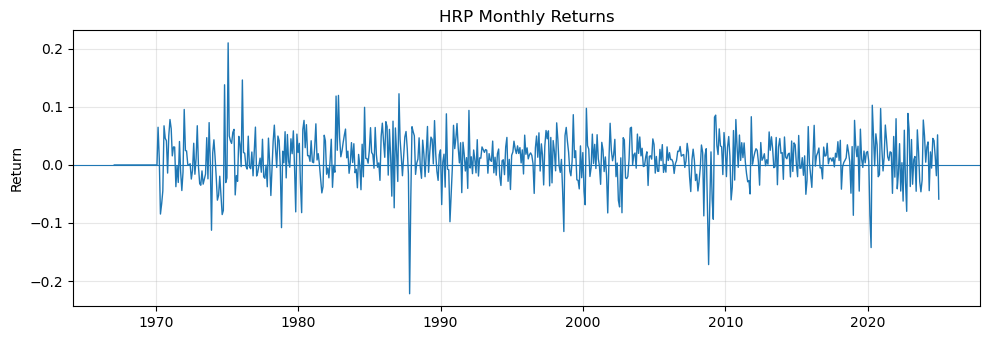

In [121]:
# monthly returns
hrp_series =hrp_port
hrp = hrp_series.dropna()

plt.figure(figsize=(10,3.5))
plt.plot(hrp.index, hrp.values, linewidth=1.0)
plt.axhline(0, linewidth=0.8)
plt.title("HRP Monthly Returns")
plt.ylabel("Return")
plt.xlabel("")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [122]:
# performance summary

ann = 12
R = combined_returns[["S&P Return", "EBC Return", "HRP Return"]].dropna()

summary = pd.DataFrame({
    "Ann Return": (1+R).prod()**(ann/len(R)) - 1,
    "Ann Vol": R.std(ddof=1)*np.sqrt(ann),
})
summary["Sharpe (rf=0)"] = summary["Ann Return"] / (summary["Ann Vol"] + 1e-12)
summary


/opt/anaconda3/lib/python3.12/site-packages/numpy/core/_methods.py:53: RuntimeWarning: overflow encountered in reduce
  return umr_prod(a, axis, dtype, out, keepdims, initial, where)


,Ann Return,Ann Vol,Sharpe (rf=0)
S&P Return,inf,9.587460,inf
EBC Return,inf,7.277852,inf
HRP Return,inf,7.091302,inf


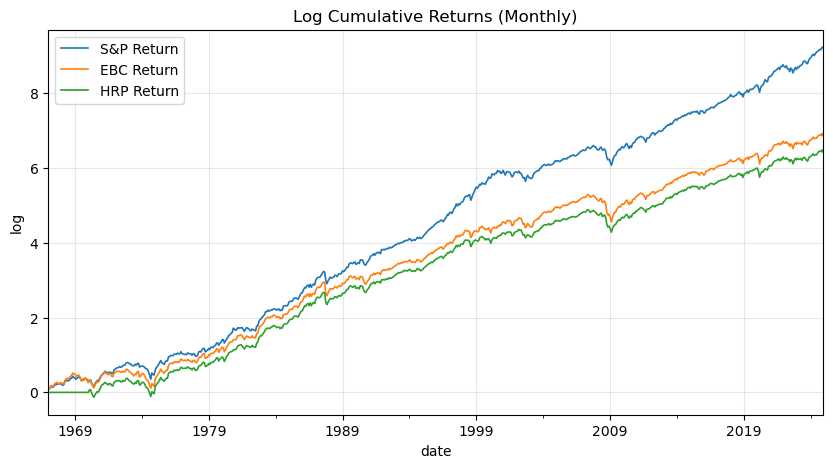

In [127]:
# cum returns curves

logcum = combined_returns[["S&P Return","EBC Return","HRP Return"]]
ax = logcum.plot(figsize=(10,5), linewidth=1.2, title="Log Cumulative Returns (Monthly)")
ax.set_ylabel("log")
ax.grid(True, alpha=0.3)


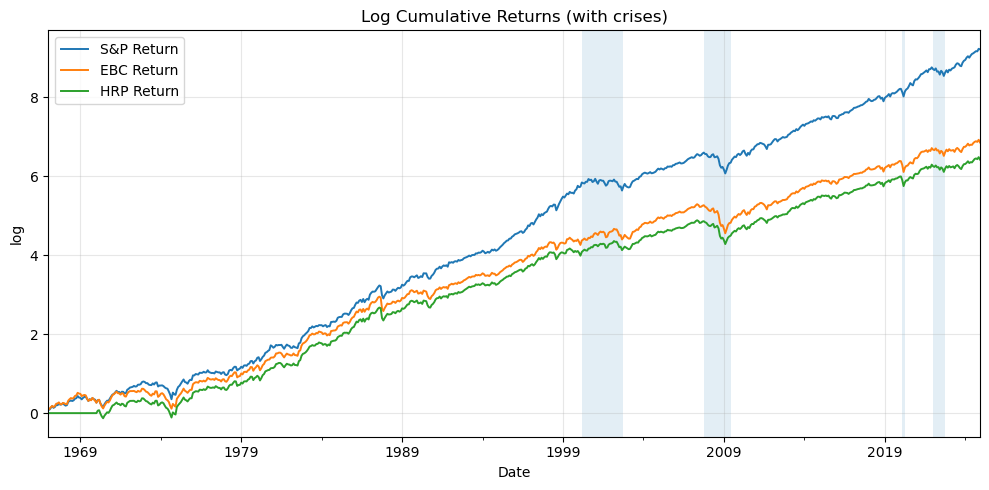

In [128]:
crises = [("2000-03-01","2002-10-31"), ("2007-10-01","2009-06-30"),
          ("2020-02-01","2020-04-30"), ("2022-01-01","2022-10-31")]

ax = logcum.plot(figsize=(10,5), linewidth=1.4, title="Log Cumulative Returns (with crises)")
for start, end in crises:
    ax.axvspan(pd.to_datetime(start), pd.to_datetime(end), alpha=0.12)
ax.set_ylabel("log")
ax.set_xlabel("Date")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


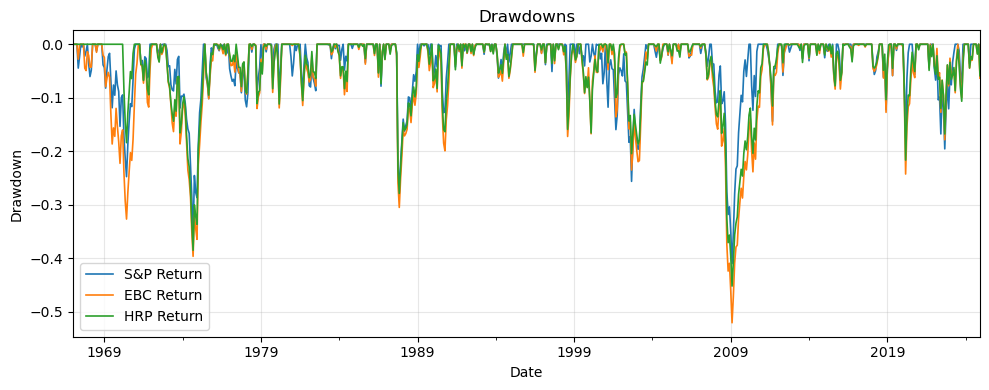

,Series,MaxDD,PeakDate,TroughDate,RecoveryDate
0,S&P Return,-0.410382,2007-10-01,2009-02-01,2010-03-01
1,EBC Return,-0.521111,2007-05-01,2009-02-01,2011-04-01
2,HRP Return,-0.452437,2007-05-01,2009-02-01,2011-02-01


In [141]:
cols = ["S&P Return", "EBC Return", "HRP Return"]
logcum = combined_returns[cols].dropna()

# DRAWDOWNS 
cum = np.exp(logcum)

# Drawdown = current / running-peak - 1
peak = cum.cummax()
dd = cum / peak - 1

# Plot drawdowns
plt.figure(figsize=(10,4))
dd.plot(ax=plt.gca(), linewidth=1.2)
plt.title("Drawdowns")
plt.ylabel("Drawdown")
plt.xlabel("Date")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Otry to get with peak/trough/recovery dates
def drawdown_summary(cum_df):
    out = []
    for c in cum_df.columns:
        series = cum_df[c].dropna()
        peak_running = series.cummax()
        dd_series = series/peak_running - 1
        trough = dd_series.idxmin()
        maxdd = dd_series.loc[trough]
        # peak date prior to trough
        peak_date = series.loc[:trough].idxmax()
        # recovery date (first time back above prior peak)
        rec = series.loc[trough:]
        recovery_date = rec[rec >= series.loc[peak_date]].index.min()
        out.append([c, float(maxdd), peak_date, trough, recovery_date])
    return pd.DataFrame(out, columns=["Series", "MaxDD", "PeakDate", "TroughDate", "RecoveryDate"])

dd_table = drawdown_summary(cum)
dd_table


In [193]:
rolling_vol[["S&P Return",'EBC Return']]

,S&P Return,EBC Return
date,,
1967-02-01,NaN,NaN
1967-03-01,NaN,NaN
1967-04-01,NaN,NaN
1967-05-01,NaN,NaN
1967-06-01,NaN,NaN
...,...,...
2024-08-01,0.293281,0.280788
2024-09-01,0.289757,0.278214
2024-10-01,0.280807,0.273749


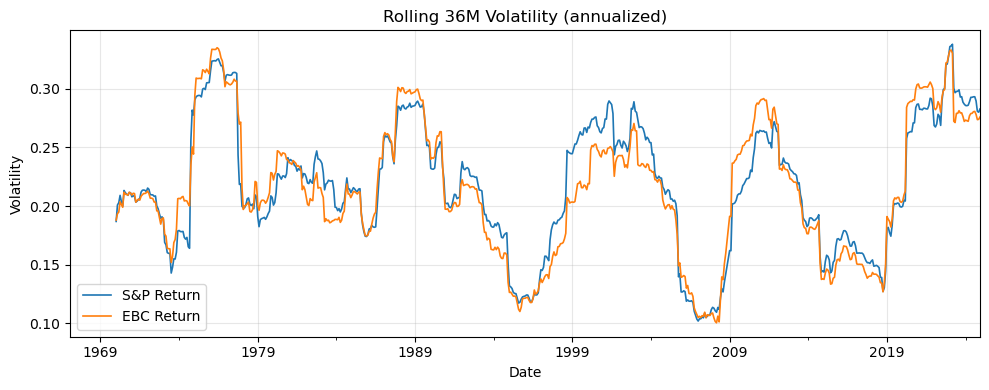

In [194]:
#  ROLLING VOLATILITY 
R = np.exp(logcum.diff()) - 1
R = R.dropna()

ann = 12           # monthly data
roll = 36          # 24-month rolling window

rolling_vol = R.rolling(roll).std(ddof=1) * np.sqrt(ann)

plt.figure(figsize=(10,4))
rolling_vol[["S&P Return",'EBC Return']].plot(ax=plt.gca(), linewidth=1.2)
plt.title(f"Rolling {roll}M Volatility (annualized)")
plt.ylabel("Volatility")
plt.xlabel("Date")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

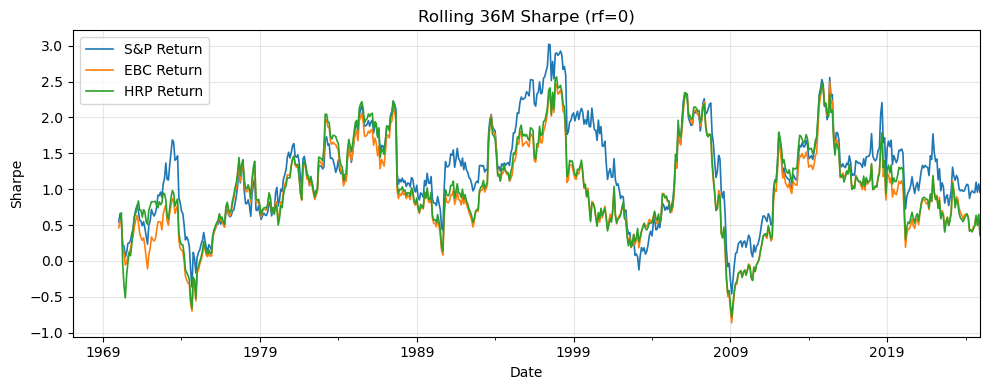

In [140]:
# ROLLING SHARPE
rolling_mean = R.rolling(roll).mean()
rolling_sharpe = (rolling_mean * ann) / (R.rolling(roll).std(ddof=1) * np.sqrt(ann))

plt.figure(figsize=(10,4))
rolling_sharpe.plot(ax=plt.gca(), linewidth=1.2)
plt.title(f"Rolling {roll}M Sharpe (rf=0)")
plt.ylabel("Sharpe")
plt.xlabel("Date")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [144]:
## Weights comparison
W_hrp



ticker,A,A.1,AAF,AAL,AAL.1,AAP,AAPL,AAV,ABA,ABBV,...,YHOO,YUM,ZA,ZB,ZBH,ZBRA,ZE,ZION,ZRN,ZTS
1970-01-31,0.001116,0.000000,0.0,0.000450,0.0,0.0,0.000000,0.0,0.000775,0.000000,...,0.0,0.000000,0.001400,0.001365,0.000000,0.000000,0.002513,0.000000,0.0,0.000000
1970-02-28,0.001505,0.000000,0.0,0.000374,0.0,0.0,0.000000,0.0,0.000729,0.000000,...,0.0,0.000000,0.001354,0.001748,0.000000,0.000000,0.001303,0.000000,0.0,0.000000
1970-03-31,0.001256,0.000000,0.0,0.000398,0.0,0.0,0.000000,0.0,0.000794,0.000000,...,0.0,0.000000,0.001188,0.001164,0.000000,0.000000,0.001207,0.000000,0.0,0.000000
1970-04-30,0.001196,0.000000,0.0,0.000407,0.0,0.0,0.000000,0.0,0.000752,0.000000,...,0.0,0.000000,0.001466,0.001209,0.000000,0.000000,0.001238,0.000000,0.0,0.000000
1970-05-31,0.001712,0.000000,0.0,0.000559,0.0,0.0,0.000000,0.0,0.000669,0.000000,...,0.0,0.000000,0.000872,0.001643,0.000000,0.000000,0.001182,0.000000,0.0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-08-31,0.000000,0.001122,0.0,0.000641,0.0,0.0,0.002633,0.0,0.000000,0.002762,...,0.0,0.002753,0.000000,0.000000,0.001892,0.000959,0.000000,0.000366,0.0,0.001652
2024-09-30,0.000000,0.002010,0.0,0.001081,0.0,0.0,0.002742,0.0,0.000000,0.004043,...,0.0,0.003197,0.000000,0.000000,0.001971,0.000578,0.000000,0.000366,0.0,0.001698
2024-10-31,0.000000,0.001141,0.0,0.000580,0.0,0.0,0.002466,0.0,0.000000,0.004754,...,0.0,0.002677,0.000000,0.000000,0.002333,0.000628,0.000000,0.000000,0.0,0.001716
2024-11-30,0.000000,0.001055,0.0,0.000548,0.0,0.0,0.003019,0.0,0.000000,0.003739,...,0.0,0.002893,0.000000,0.000000,0.002694,0.000877,0.000000,0.000000,0.0,0.001609


In [145]:
equal_abs_beta_weights

ticker,A,A.1,AAF,AAL,AAL.1,AAP,AAPL,AAV,ABA,ABBV,...,YHOO,YUM,ZA,ZB,ZBH,ZBRA,ZE,ZION,ZRN,ZTS
date,,,,,,,,,,,,,,,,,,,,,
1967-01-31,0.001002,0.000000,0.0,0.001041,0.0,0.0,0.000000,0.0,0.002034,0.000000,...,0.0,0.000000,0.001633,0.001978,0.000000,0.000000,0.001902,0.0,0.0,0.000000
1967-02-28,0.001010,0.000000,0.0,0.001107,0.0,0.0,0.000000,0.0,0.001835,0.000000,...,0.0,0.000000,0.001137,0.002339,0.000000,0.000000,0.001531,0.0,0.0,0.000000
1967-03-31,0.000977,0.000000,0.0,0.001094,0.0,0.0,0.000000,0.0,0.001831,0.000000,...,0.0,0.000000,0.001183,0.002301,0.000000,0.000000,0.001581,0.0,0.0,0.000000
1967-04-30,0.001073,0.000000,0.0,0.001091,0.0,0.0,0.000000,0.0,0.001602,0.000000,...,0.0,0.000000,0.001270,0.002080,0.000000,0.000000,0.001695,0.0,0.0,0.000000
1967-05-31,0.001065,0.000000,0.0,0.001124,0.0,0.0,0.000000,0.0,0.001559,0.000000,...,0.0,0.000000,0.001312,0.001902,0.000000,0.000000,0.001555,0.0,0.0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-08-31,0.000000,0.001612,0.0,0.001466,0.0,0.0,0.001720,0.0,0.000000,0.003488,...,0.0,0.002517,0.000000,0.000000,0.002524,0.001179,0.000000,0.0,0.0,0.001876
2024-09-30,0.000000,0.001674,0.0,0.001483,0.0,0.0,0.001680,0.0,0.000000,0.003865,...,0.0,0.002578,0.000000,0.000000,0.002521,0.001247,0.000000,0.0,0.0,0.001933
2024-10-31,0.000000,0.001701,0.0,0.000000,0.0,0.0,0.001715,0.0,0.000000,0.003699,...,0.0,0.002607,0.000000,0.000000,0.002493,0.001204,0.000000,0.0,0.0,0.001867


In [183]:
ticker_example = 'IBM'

def pick_col_case_insensitive(df, symbol=ticker_example):
    m = {c.lower(): c for c in df.columns}
    if symbol.lower() not in m:
        raise KeyError(f"{symbol} not found in columns")
    return m[symbol.lower()]


col_hrp  = pick_col_case_insensitive(W_hrp, ticker_example)
col_ebc  = pick_col_case_insensitive(equal_abs_beta_weights, ticker_example)

# check date alignment because it's always messed up
def to_month_end_index(s: pd.Series) -> pd.Series:
    idx = pd.to_datetime(s.index) + pd.offsets.MonthEnd(0)
    s = s.copy()
    s.index = idx
    return s.sort_index()

aapl_hrp = to_month_end_index(W_hrp[col_hrp]).rename("HRP")
aapl_ebc = to_month_end_index(equal_abs_beta_weights[col_ebc]).rename("EBC")

aapl = pd.concat([aapl_hrp, aapl_ebc], axis=1).reindex(
    aapl_hrp.index.union(aapl_ebc.index)
).fillna(0.0)


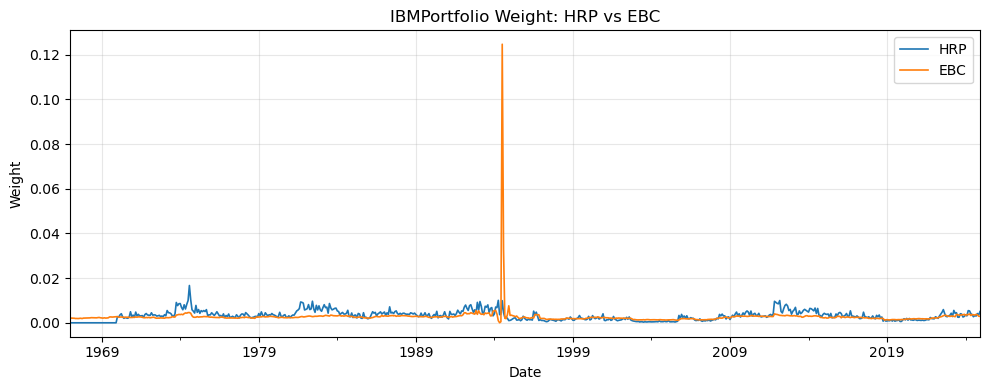

In [184]:
plt.figure(figsize=(10,4))
aapl.plot(ax=plt.gca(), linewidth=1.2)
plt.title(ticker_example +"Portfolio Weight: HRP vs EBC")
plt.ylabel("Weight")
plt.xlabel("Date")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [182]:
summary = pd.Series({
    "Mean weight HRP":   aapl["HRP"].mean(),
    "Mean weight EBC":   aapl["EBC"].mean(),
    "Median HRP":        aapl["HRP"].median(),
    "Median EBC":        aapl["EBC"].median(),
    "Max HRP":           aapl["HRP"].max(),
    "Max HRP date":      aapl["HRP"].idxmax(),
    "Max EBC":           aapl["EBC"].max(),
    "Max EBC date":      aapl["EBC"].idxmax(),
    "% months active HRP": (aapl["HRP"] > 0).mean(),
    "% months active EBC": (aapl["EBC"] > 0).mean(),
    "Corr(HRP, EBC)":    aapl["HRP"].corr(aapl["EBC"]),
    "Mean (HRP - EBC)":  (aapl["HRP"] - aapl["EBC"]).mean(),
})
summary


Mean weight HRP                   0.004233
Mean weight EBC                   0.003227
Median HRP                        0.003669
Median EBC                        0.003131
Max HRP                           0.024069
Max HRP date           1991-01-31 00:00:00
Max EBC                            0.00727
Max EBC date           2002-02-28 00:00:00
% months active HRP               0.948276
% months active EBC                    1.0
Corr(HRP, EBC)                    0.514578
Mean (HRP - EBC)                  0.001006
dtype: object

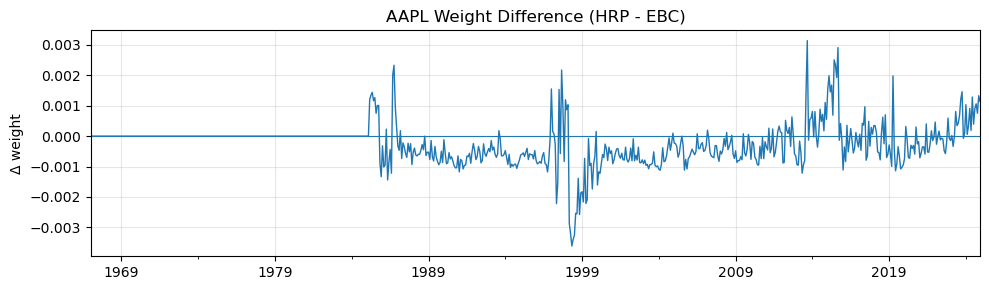

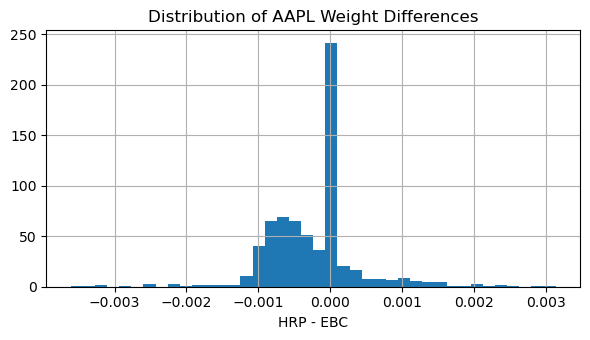

In [155]:
diff = (aapl["HRP"] - aapl["EBC"]).rename("HRP - EBC")
plt.figure(figsize=(10,3))
diff.plot(ax=plt.gca(), linewidth=1.0)
plt.title(ticker_example +" Weight Difference (HRP - EBC)")
plt.axhline(0, linewidth=0.8)
plt.ylabel("Δ weight")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(6,3.5))
diff.hist(bins=40)
plt.title("Distribution of AAPL Weight Differences")
plt.xlabel("HRP - EBC")
plt.tight_layout()
plt.show()


In [151]:
crises = {
    "Dotcom": ("2000-03-01","2002-10-31"),
    "GFC":    ("2007-10-01","2009-06-30"),
    "COVID":  ("2020-02-01","2020-04-30"),
    "2022":   ("2022-01-01","2022-10-31"),
}
rows = []
for k,(s,e) in crises.items():
    sl = aapl.loc[s:e]
    rows.append([k, sl["HRP"].mean(), sl["EBC"].mean()])
pd.DataFrame(rows, columns=["Window","AAPL HRP mean w","AAPL EBC mean w"])


,Window,AAPL HRP mean w,AAPL EBC mean w
0,Dotcom,0.000774,0.001412
1,GFC,0.000660,0.001149
2,COVID,0.001732,0.001890
3,2022,0.001553,0.001670


In [156]:
## overall weight comparison for full portfolio

def align_weight_panels(W_hrp: pd.DataFrame, W_ebc: pd.DataFrame):
    # same columns
    cols = W_hrp.columns.union(W_ebc.columns)
    W1 = W_hrp.reindex(columns=cols, fill_value=0.0)
    W2 = W_ebc.reindex(columns=cols, fill_value=0.0)
    # same dates (intersection)
    idx = W1.index.intersection(W2.index)
    W1 = W1.loc[idx].sort_index()
    W2 = W2.loc[idx].sort_index()
    return W1, W2

W1, W2 = align_weight_panels(W_hrp, equal_abs_beta_weights)


In [157]:
W1

ticker,A,A.1,AAF,AAL,AAL.1,AAP,AAPL,AAV,ABA,ABBV,...,YHOO,YUM,ZA,ZB,ZBH,ZBRA,ZE,ZION,ZRN,ZTS
1970-01-31,0.001116,0.000000,0.0,0.000450,0.0,0.0,0.000000,0.0,0.000775,0.000000,...,0.0,0.000000,0.001400,0.001365,0.000000,0.000000,0.002513,0.000000,0.0,0.000000
1970-02-28,0.001505,0.000000,0.0,0.000374,0.0,0.0,0.000000,0.0,0.000729,0.000000,...,0.0,0.000000,0.001354,0.001748,0.000000,0.000000,0.001303,0.000000,0.0,0.000000
1970-03-31,0.001256,0.000000,0.0,0.000398,0.0,0.0,0.000000,0.0,0.000794,0.000000,...,0.0,0.000000,0.001188,0.001164,0.000000,0.000000,0.001207,0.000000,0.0,0.000000
1970-04-30,0.001196,0.000000,0.0,0.000407,0.0,0.0,0.000000,0.0,0.000752,0.000000,...,0.0,0.000000,0.001466,0.001209,0.000000,0.000000,0.001238,0.000000,0.0,0.000000
1970-05-31,0.001712,0.000000,0.0,0.000559,0.0,0.0,0.000000,0.0,0.000669,0.000000,...,0.0,0.000000,0.000872,0.001643,0.000000,0.000000,0.001182,0.000000,0.0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-08-31,0.000000,0.001122,0.0,0.000641,0.0,0.0,0.002633,0.0,0.000000,0.002762,...,0.0,0.002753,0.000000,0.000000,0.001892,0.000959,0.000000,0.000366,0.0,0.001652
2024-09-30,0.000000,0.002010,0.0,0.001081,0.0,0.0,0.002742,0.0,0.000000,0.004043,...,0.0,0.003197,0.000000,0.000000,0.001971,0.000578,0.000000,0.000366,0.0,0.001698
2024-10-31,0.000000,0.001141,0.0,0.000580,0.0,0.0,0.002466,0.0,0.000000,0.004754,...,0.0,0.002677,0.000000,0.000000,0.002333,0.000628,0.000000,0.000000,0.0,0.001716
2024-11-30,0.000000,0.001055,0.0,0.000548,0.0,0.0,0.003019,0.0,0.000000,0.003739,...,0.0,0.002893,0.000000,0.000000,0.002694,0.000877,0.000000,0.000000,0.0,0.001609


In [158]:
W2

ticker,A,A.1,AAF,AAL,AAL.1,AAP,AAPL,AAV,ABA,ABBV,...,YHOO,YUM,ZA,ZB,ZBH,ZBRA,ZE,ZION,ZRN,ZTS
1970-01-31,0.001674,0.000000,0.0,0.001318,0.0,0.0,0.000000,0.0,0.001278,0.000000,...,0.0,0.000000,0.002202,0.002112,0.000000,0.000000,0.001918,0.0,0.0,0.000000
1970-02-28,0.001736,0.000000,0.0,0.001244,0.0,0.0,0.000000,0.0,0.001359,0.000000,...,0.0,0.000000,0.003189,0.001825,0.000000,0.000000,0.002393,0.0,0.0,0.000000
1970-03-31,0.001756,0.000000,0.0,0.001168,0.0,0.0,0.000000,0.0,0.001359,0.000000,...,0.0,0.000000,0.003680,0.001921,0.000000,0.000000,0.002264,0.0,0.0,0.000000
1970-04-30,0.001651,0.000000,0.0,0.001155,0.0,0.0,0.000000,0.0,0.001437,0.000000,...,0.0,0.000000,0.003349,0.001965,0.000000,0.000000,0.002185,0.0,0.0,0.000000
1970-05-31,0.001883,0.000000,0.0,0.001219,0.0,0.0,0.000000,0.0,0.001680,0.000000,...,0.0,0.000000,0.002797,0.002095,0.000000,0.000000,0.002196,0.0,0.0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-08-31,0.000000,0.001612,0.0,0.001466,0.0,0.0,0.001720,0.0,0.000000,0.003488,...,0.0,0.002517,0.000000,0.000000,0.002524,0.001179,0.000000,0.0,0.0,0.001876
2024-09-30,0.000000,0.001674,0.0,0.001483,0.0,0.0,0.001680,0.0,0.000000,0.003865,...,0.0,0.002578,0.000000,0.000000,0.002521,0.001247,0.000000,0.0,0.0,0.001933
2024-10-31,0.000000,0.001701,0.0,0.000000,0.0,0.0,0.001715,0.0,0.000000,0.003699,...,0.0,0.002607,0.000000,0.000000,0.002493,0.001204,0.000000,0.0,0.0,0.001867
2024-11-30,0.000000,0.001592,0.0,0.000000,0.0,0.0,0.001690,0.0,0.000000,0.004143,...,0.0,0.002542,0.000000,0.000000,0.002388,0.001204,0.000000,0.0,0.0,0.001921


In [163]:
def topk_overlap_fraction(w1: pd.Series, w2: pd.Series, k: int = 10):
    w1 = w1.fillna(0.0)
    w2 = w2.fillna(0.0)
    k_eff = int(min(k, (w1 != 0).sum(), (w2 != 0).sum(), len(w1), len(w2)))
    if k_eff <= 0:
        return np.nan
    i1 = set(w1.nlargest(k_eff).index)
    i2 = set(w2.nlargest(k_eff).index)
    return len(i1 & i2) / float(k_eff)

# show per month
tv_dist   = 0.5 * (W1 - W2).abs().sum(axis=1)                 # Active Share / TV distance (range is 0-1. 0 the same and 1 completely different)
hhi_hrp   = (W1.pow(2)).sum(axis=1)
hhi_ebc   = (W2.pow(2)).sum(axis=1)
effN_hrp  = 1.0 / hhi_hrp.replace(0, np.nan)                  # Effective number of names --> high value: more spread out more diversified
effN_ebc  = 1.0 / hhi_ebc.replace(0, np.nan)
top10_overlap = pd.Series({d: topk_overlap_fraction(W1.loc[d], W2.loc[d], 10) for d in W1.index})  # are the leaders/ top stocks the same

metrics = pd.DataFrame({
    "TV_Distance": tv_dist,
    "EffN_HRP": effN_hrp,
    "EffN_EBC": effN_ebc,
    "Top10_Overlap": top10_overlap,
})

metrics.tail()


,TV_Distance,EffN_HRP,EffN_EBC,Top10_Overlap
2024-08-31,0.219507,294.935917,278.932199,0.2
2024-09-30,0.201657,295.088691,396.524511,0.1
2024-10-31,0.203074,285.771902,363.050153,0.0
2024-11-30,0.193903,284.226293,386.758363,0.3
2024-12-31,0.208135,283.310605,387.701415,0.2


In [161]:
# top differet assets by average absolute difference
avg_abs_diff = (W1 - W2).abs().mean(axis=0).sort_values(ascending=False)
top20 = avg_abs_diff.head(20).to_frame("AvgAbsDiff")
top20


,AvgAbsDiff
ticker,
HSY,0.003759
GIS,0.003145
DUK,0.002826
K,0.002764
WWY,0.002746
ED,0.002721
PG,0.002516
EXC,0.002492
SO,0.002451


In [168]:
#make returns df

# some are series others no 
def as_series(x, name):
    if isinstance(x, pd.Series):
        return x.rename(name)
    if isinstance(x, pd.DataFrame):
        if x.shape[1] != 1:
            raise ValueError(f"{name} has {x.shape[1]} cols; expected 1")
        return x.iloc[:, 0].rename(name)
    arr = np.asarray(x).squeeze()
    if arr.ndim != 1:
        raise ValueError(f"{name} not 1-D after squeeze; shape {arr.shape}")
    return pd.Series(arr, name=name)

s_sp  = as_series(sp500_returns,              "S&P Return")
s_ebc = as_series(equal_beta_portfolio_return,"EBC Return")
s_hrp = as_series(hrp_port,                   "HRP Return")

# month end and month start
for s in (s_sp, s_ebc, s_hrp):
    s.index = pd.to_datetime(s.index).to_period("M")

# set to target index
idx_p = pd.to_datetime(target_index).to_period("M")
reg_returns = pd.concat([s_sp, s_ebc, s_hrp], axis=1).reindex(idx_p)

reg_returns.index = idx_p.to_timestamp()


In [169]:
reg_returns

,S&P Return,EBC Return,HRP Return
date,,,
1967-01-01,0.083415,0.105809,0.000000
1967-02-01,0.010039,0.007303,0.000000
1967-03-01,0.044007,0.043577,0.000000
1967-04-01,0.047458,0.032736,0.000000
1967-05-01,-0.044615,-0.027935,0.000000
...,...,...,...
2024-08-01,0.028116,0.030202,0.041952
2024-09-01,0.025856,0.016253,0.015083
2024-10-01,-0.004786,-0.016896,-0.018519


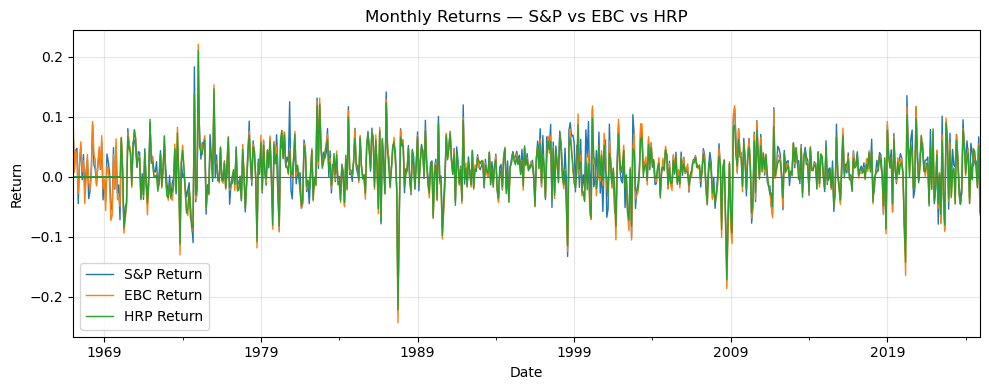

In [171]:
R = reg_returns.copy()  # columns: "S&P Return", "EBC Return", "HRP Return"

plt.figure(figsize=(10,4))
R.plot(ax=plt.gca(), linewidth=1.0)
plt.axhline(0, linewidth=0.8)
plt.title("Monthly Returns — S&P vs EBC vs HRP")
plt.ylabel("Return")
plt.xlabel("Date")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
